# Try out different distance metrics

In [1]:
from os.path import join, isfile
from typing import Dict, List

import anndata
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "/vol/data/dataset-similarity"
FILE_PATH = "adata.h5ad"

if not isfile(FILE_PATH):
    adata = anndata.concat([
        sc.read_h5ad(join(DATA_PATH, "01ad3cd7-3929-4654-84c0-6db05bd5fd59_processed.h5ad")),
        sc.read_h5ad(join(DATA_PATH, "b0e547f0-462b-4f81-b31b-5b0a5d96f537_processed.h5ad"))
    ], label="dataset", keys=["ref", "query"])
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    sc.tl.pca(adata, n_comps=256)
    adata.write_h5ad(FILE_PATH)
else:
    print("Loading cached anndata file...")
    adata = anndata.read_h5ad(FILE_PATH)


Loading cached anndata file...


In [3]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key='dataset')
adata = adata[:, adata.var.highly_variable]

/vol/data/miniconda3/envs/similarity/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/vol/data/miniconda3/envs/similarity/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/vol/data/miniconda3/envs/similarity/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:508: FutureWarning: The provided callable <function nanmean at 0x7f6a

In [4]:
adata

View of AnnData object with n_obs × n_vars = 1659838 × 2000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'cell_type_author', 'dataset'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'pca', 'hvg'
    obsm: 'X_pca'
    varm: 'PCs'

In [5]:
adata_ref = adata[adata.obs.dataset == "ref"]
adata_query = adata[adata.obs.dataset == "query"]

In [45]:
def plot_label_distances(
    label_distances: np.ndarray, 
    labels1: List[str], 
    labels2: List[str],
    author_to_cxg_celltype: Dict[str, str]
):
    distances = pd.DataFrame(
        data=label_distances,
        index=labels1,
        columns=labels2
    )
    
    order = lambda ct_author: list(
        map(
            lambda x: x[0], # only return author cell type
            sorted(
                zip(
                    ct_author, 
                    [author_to_cxg_celltype[ct] for ct in ct_author]
                ), 
                key=lambda x: x[1]
            ) # sort by CxG cell type
        )
    )

    fig, ax = plt.subplots(figsize=(12, 12))
    sns.heatmap(
        distances.loc[order(labels1), :].loc[:, order(labels2)], 
        square=True
    )

    return ax


In [7]:
author_to_cxg_mapping = (
    adata.obs[["cell_type", "cell_type_author"]]
    .drop_duplicates()
    .set_index("cell_type_author")["cell_type"]
    .to_dict()
)

## Bures-Wasserstein distance in PCA space

In [7]:
from datasim.label_distance import bures_wasserstein_label_distance

In [8]:
bw_distance_128 = bures_wasserstein_label_distance(
    adata_ref.obsm["X_pca"][:, :128],
    adata_query.obsm["X_pca"][:, :128],
    adata_ref.obs.cell_type_author.to_numpy(),
    adata_query.obs.cell_type_author.to_numpy()
)

Calcualting mean vectors...
Calcualting covariance matrices...
Computing label distances...


  0%|          | 0/1360 [00:00<?, ?it/s]

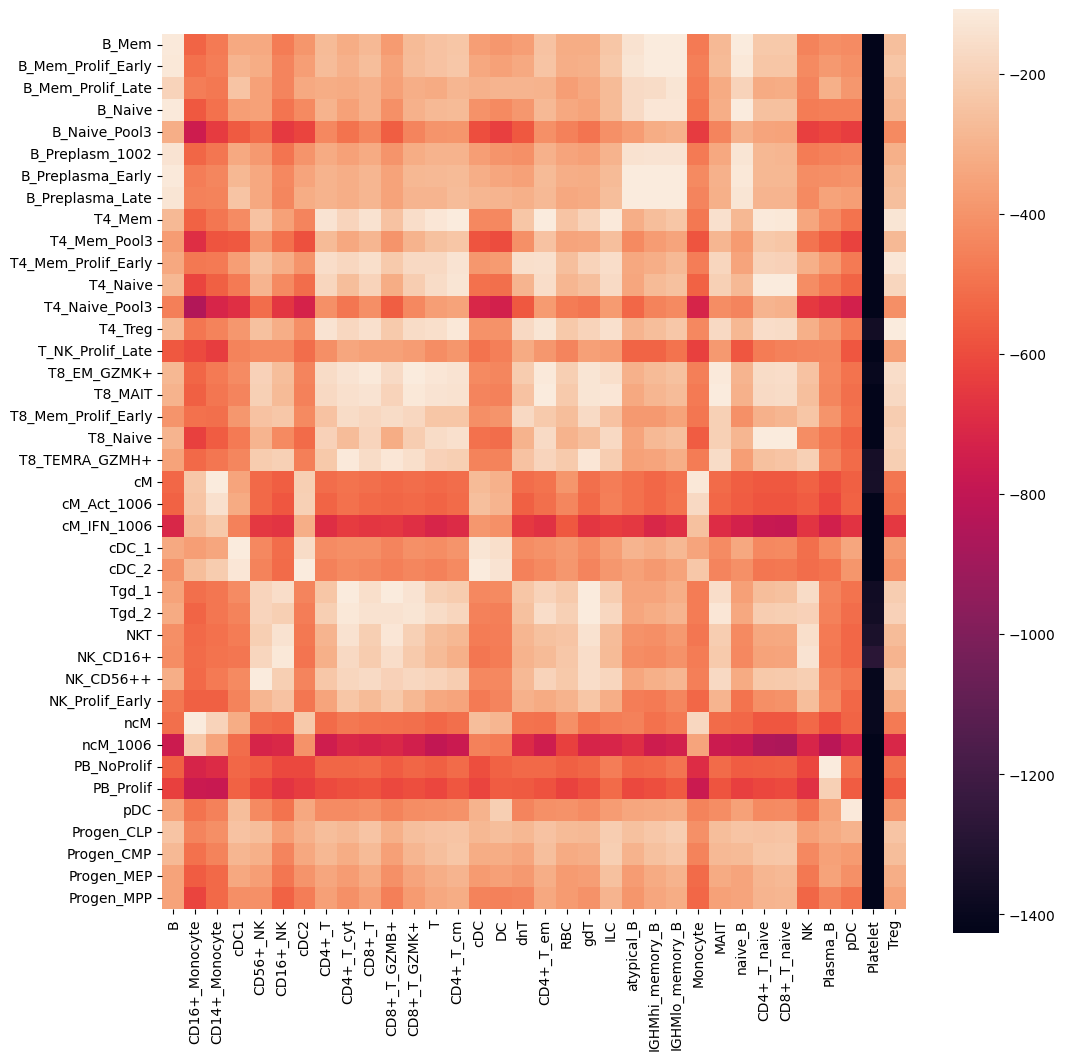

In [9]:
ax = plot_label_distances(
    -bw_distance_128.to_numpy(), 
    bw_distance_128.index.tolist(), 
    bw_distance_128.columns.tolist(), 
    author_to_cxg_mapping
)

## Spearman correlation of centroids

In [10]:
from datasim.label_distance import spearmanr_label_distance

In [11]:
spearmanr_distance = spearmanr_label_distance(
    adata_ref.X,
    adata_query.X,
    adata_ref.obs.cell_type_author.to_numpy(),
    adata_query.obs.cell_type_author.to_numpy()
)

Calculating mean vectors...
Computing label distances...


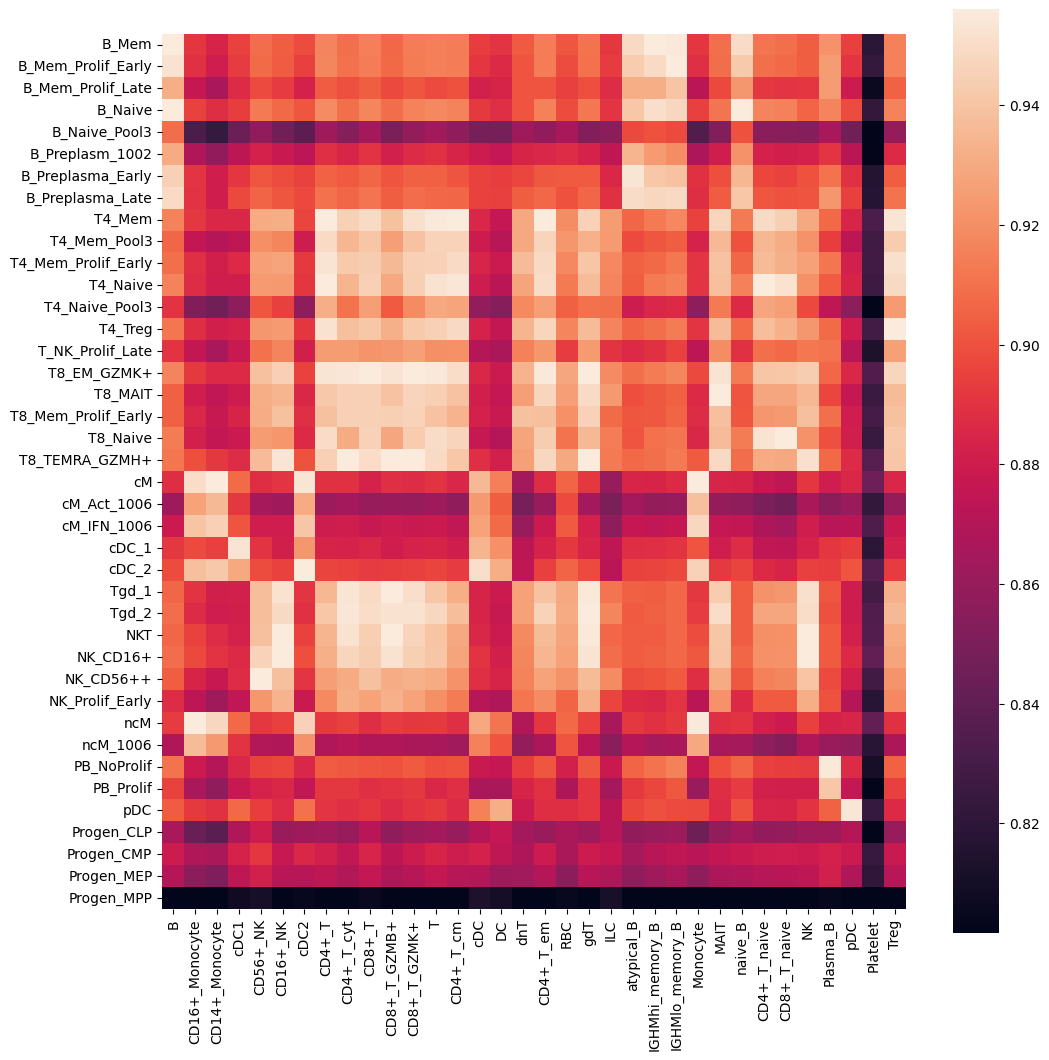

In [12]:
ax = plot_label_distances(
    spearmanr_distance.to_numpy(), 
    spearmanr_distance.index.tolist(), 
    spearmanr_distance.columns.tolist(), 
    author_to_cxg_mapping
)

## Overlap of differentially expressed genes

In [33]:
N_GENES = 50

In [ ]:
sc.tl.rank_genes_groups(adata_ref, groupby="cell_type_author", n_genes=N_GENES)

In [ ]:
sc.tl.rank_genes_groups(adata_query, groupby="cell_type_author", n_genes=N_GENES)

In [36]:
de_genes_ref = {}
for celltype in adata_ref.obs.cell_type_author.unique():
    de_genes_ref[celltype] = adata_ref.uns["rank_genes_groups"]["names"][celltype].tolist()

de_genes_query = {}
for celltype in adata_query.obs.cell_type_author.unique():
    de_genes_query[celltype] = adata_query.uns["rank_genes_groups"]["names"][celltype].tolist()

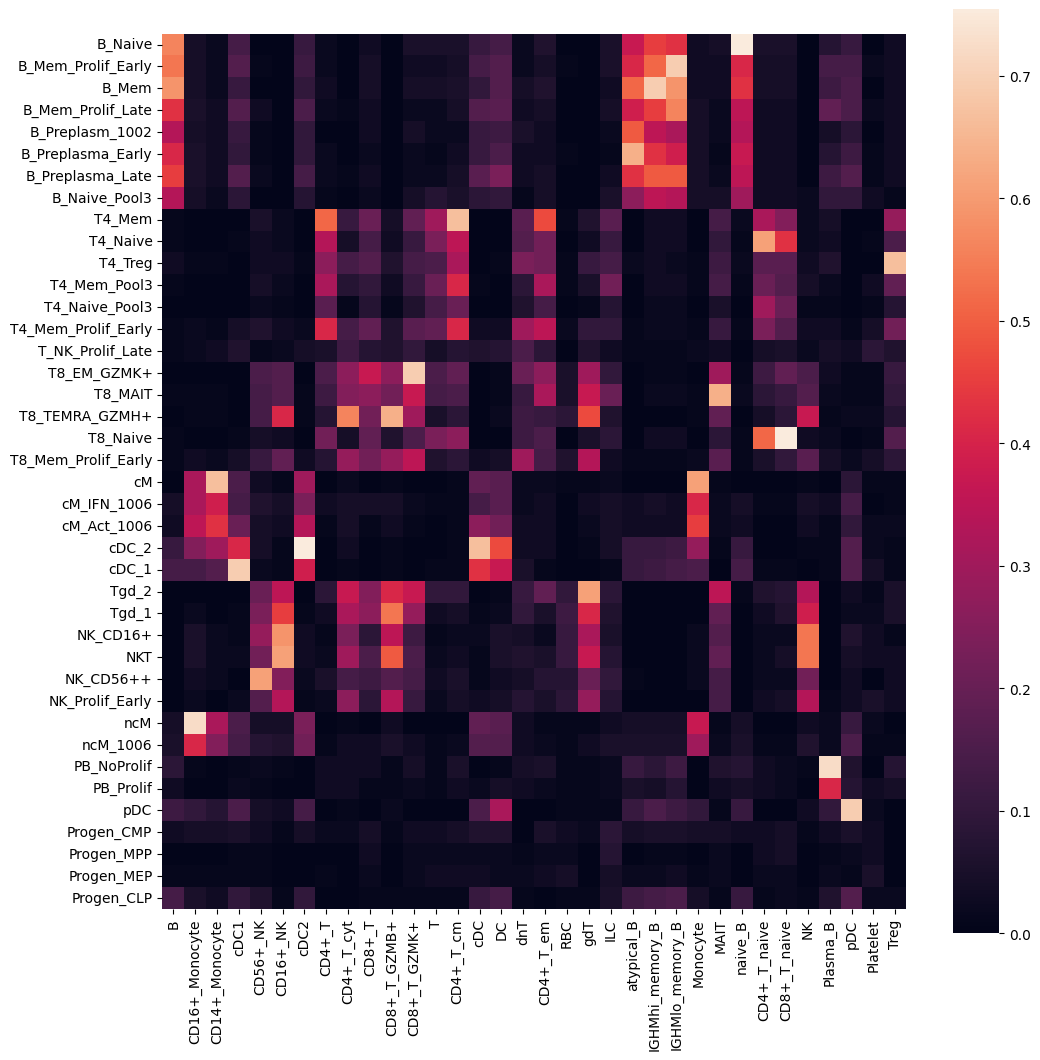

In [46]:
de_gene_overlap = sc.tl.marker_gene_overlap(adata_query, de_genes_ref, method="jaccard")

ax = plot_label_distances(
    de_gene_overlap.to_numpy(), 
    de_gene_overlap.index.tolist(), 
    de_gene_overlap.columns.tolist(), 
    author_to_cxg_mapping
)